Generated: castlefield_equalizer_black_axis.png


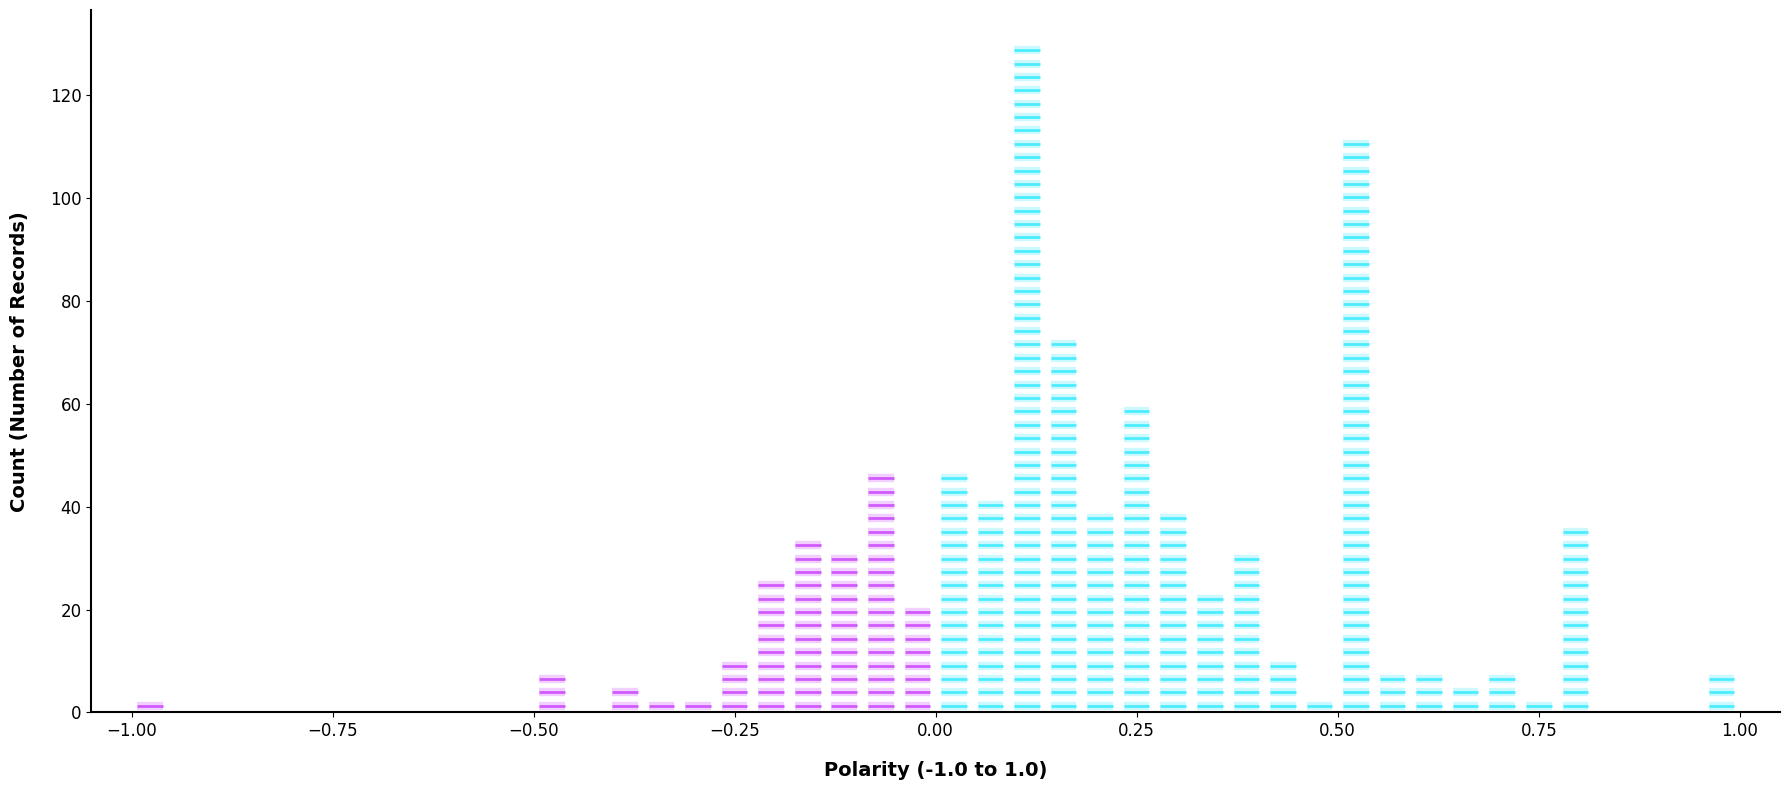

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Read data and filter out the absolute neutral polarity (0.0)
df = pd.read_csv('castlefield_sentiment_data.csv')
polarities = df[df['polarity'] != 0.0]['polarity'].values

# Set up bins for the histogram
bins = np.linspace(-1, 1, 45)
counts, bin_edges = np.histogram(polarities, bins=bins)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
bin_width = bin_edges[1] - bin_edges[0]

# Set up a transparent canvas
fig, ax = plt.subplots(figsize=(18, 8))
fig.patch.set_alpha(0.0)
ax.patch.set_alpha(0.0)

color_pos = '#00e5ff' # Neon Cyan
color_neg = '#bc13fe' # Neon Purple

# Draw LED equalizer-style stacked horizontal lines
# Set the height step for each horizontal line to create a gap effect
y_step = max(counts) / 50.0  # Divide the tallest bar into approximately 50 horizontal strips

for x, count in zip(bin_centers, counts):
    if count == 0:
        continue

    color = color_pos if x > 0 else color_neg

    # Draw horizontal lines at intervals from the bottom up to the bar's count
    y_vals = np.arange(y_step/2, count, y_step)

    for y in y_vals:
        # Define the width of the line (X-axis span) based on available bin width
        x_min = x - bin_width * 0.35
        x_max = x + bin_width * 0.35

        # 1. Glow layer (thick, high transparency)
        ax.hlines(y, x_min, x_max, color=color, linewidth=6, alpha=0.2)
        # 2. Core layer (thin, bright) - kept white to maintain the neon tube effect inside the bars
        ax.hlines(y, x_min, x_max, color='white', linewidth=2, alpha=0.9)
        ax.hlines(y, x_min, x_max, color=color, linewidth=2, alpha=0.7)

# Minimalist axis styling
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Keep the left Y-axis spine visible, make it black and adjust thickness
ax.spines['left'].set_visible(True)
ax.spines['left'].set_color('black')
ax.spines['left'].set_linewidth(1.5)

# Keep the bottom X-axis spine visible, make it black and adjust thickness
ax.spines['bottom'].set_color('black')
ax.spines['bottom'].set_linewidth(1.5)

# Show Y-axis ticks on the left and set tick colors to black
ax.tick_params(colors='black', labelsize=12, left=True)

# Set axis labels to black
ax.set_xlabel('Polarity (-1.0 to 1.0)', color='black', fontsize=14, labelpad=15, fontweight='bold')
ax.set_ylabel('Count (Number of Records)', color='black', fontsize=14, labelpad=15, fontweight='bold')

# Set axis limits
ax.set_xlim(-1.05, 1.05)
ax.set_ylim(0, max(counts) * 1.05)

# Save as a high-resolution PNG with a transparent background
output_file = 'castlefield_equalizer_black_axis.png'
plt.tight_layout()
plt.savefig(output_file, dpi=300, transparent=True)
print(f"Generated: {output_file}")